In [1]:
from pathlib import Path
import os
import natsort
import mne
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

mne.set_log_level("CRITICAL")

sns.set()

save_base = Path("./figures")
save_base.mkdir(exist_ok=True, parents=True)


In [2]:
fname = "../results/classification_results.csv"

df = pd.read_csv(fname)

df

,subject,dataset,model,epoch_window,accuracy
0,1,Lee2019_MI,Deep4Net,w_00_30,0.83000
1,1,Lee2019_MI,Deep4Net,w_05_35,0.77000
2,2,Lee2019_MI,Deep4Net,w_00_30,0.79000
3,2,Lee2019_MI,Deep4Net,w_05_35,0.74000
4,3,Lee2019_MI,Deep4Net,w_00_30,0.84000
...,...,...,...,...,...
721,85,Dreyer2023_wo_p,Deep4Net,w_00_40,0.81875
722,86,Dreyer2023_wo_p,Deep4Net,w_05_45,0.69375
723,86,Dreyer2023_wo_p,Deep4Net,w_00_40,0.86875
724,87,Dreyer2023_wo_p,Deep4Net,w_05_45,0.89375


In [3]:
dataset_name = "Dreyer2023"
#dataset_name = "Lee2019_MI"

model = "Deep4Net"

if dataset_name == "Dreyer2023":
    window_with_cue = "w_00_40"
    window_without_cue = "w_05_45"
elif dataset_name == "Lee2019_MI":
    window_with_cue = "w_00_30"
    window_without_cue = "w_05_35"

df = df[df["dataset"] == dataset_name]
df = df[df["model"] == model]

with_cue = df[df["epoch_window"] == window_with_cue]
without_cue = df[df["epoch_window"] == window_without_cue]

with_cue = with_cue.sort_values("subject")
without_cue = without_cue.sort_values("subject")

diff = pd.DataFrame()
diff["subject"] = with_cue["subject"].tolist()
diff["diff"] = with_cue["accuracy"].to_numpy() - without_cue["accuracy"].to_numpy()

median = diff.median()["diff"]
print(median)

diff


0.11875000000000002


,subject,diff
0,1,0.10625
1,2,0.19375
2,3,0.30625
3,4,0.11875
4,5,0.23750
...,...,...
80,83,-0.01250
81,84,0.10000
82,85,-0.00625
83,86,0.15625


In [4]:
big = diff[diff["diff"] >= median]["subject"].tolist()
small = diff[diff["diff"] < median]["subject"].tolist()

print("big", big)
print("small", small)

big [2, 3, 4, 5, 6, 8, 12, 14, 15, 19, 26, 28, 29, 30, 31, 32, 33, 34, 36, 37, 42, 43, 44, 45, 47, 49, 51, 53, 54, 57, 60, 63, 64, 68, 70, 71, 72, 73, 77, 80, 81, 82, 86]
small [1, 7, 9, 10, 11, 13, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 35, 38, 39, 41, 46, 48, 50, 52, 55, 56, 58, 61, 62, 65, 66, 67, 69, 74, 75, 76, 78, 79, 83, 84, 85, 87]


In [5]:
def load_evoked(dataset_name, subjects):
    base = Path("../Dataset") / "evoked" / dataset_name

    files = natsort.natsorted(os.listdir(base))

    new_files = []
    for sub in subjects:
        for file in files:
            if f"sub-{sub}_" in file:
                new_files.append(file)
    files = new_files

    left_hand = [f for f in files if "left_hand" in f]
    right_hand = [f for f in files if "right_hand" in f]

    left_hand_evokeds_list = []
    for f in left_hand:
        evoked_left = mne.read_evokeds(base / f)
        evoked_left[0].pick(picks="eeg")
        left_hand_evokeds_list.append(evoked_left[0])

    right_hand_evokeds_list = []
    for f in right_hand:
        evoked_right = mne.read_evokeds(base / f)
        evoked_right[0].pick(picks="eeg")
        right_hand_evokeds_list.append(evoked_right[0])

    left_hand_evoked = mne.combine_evoked(left_hand_evokeds_list, weights="equal")
    right_hand_evoked = mne.combine_evoked(right_hand_evokeds_list, weights="equal")

    return left_hand_evoked, right_hand_evoked


def load_signed_r2(dataset_name, subjects):
    base = Path("../Dataset") / "signed_r2" / dataset_name

    files = natsort.natsorted(os.listdir(base))

    new_files = []
    for sub in subjects:
        for file in files:
            if f"sub-{sub}_" in file:
                new_files.append(file)
    files = new_files

    files_load = [f for f in files if "signed_r2-ave" in f]

    signed_r2_list = []
    for file in files_load:
        e = mne.read_evokeds(base / file)[0]
        signed_r2_list.append(e)
    signed_r2 = mne.combine_evoked(signed_r2_list, weights="equal")

    return signed_r2




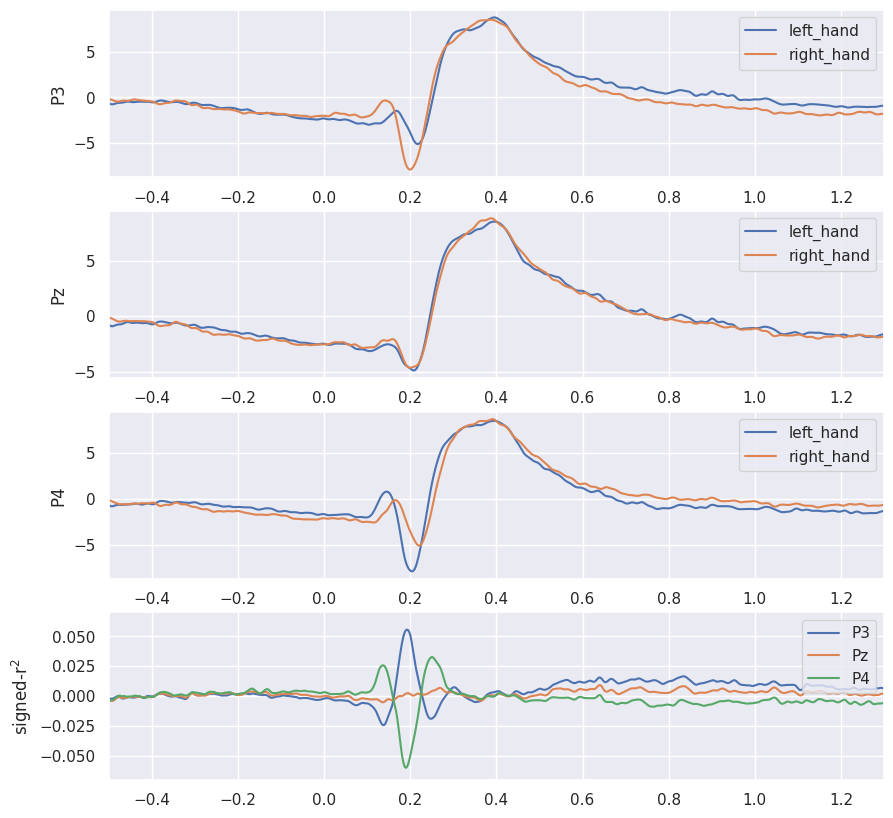

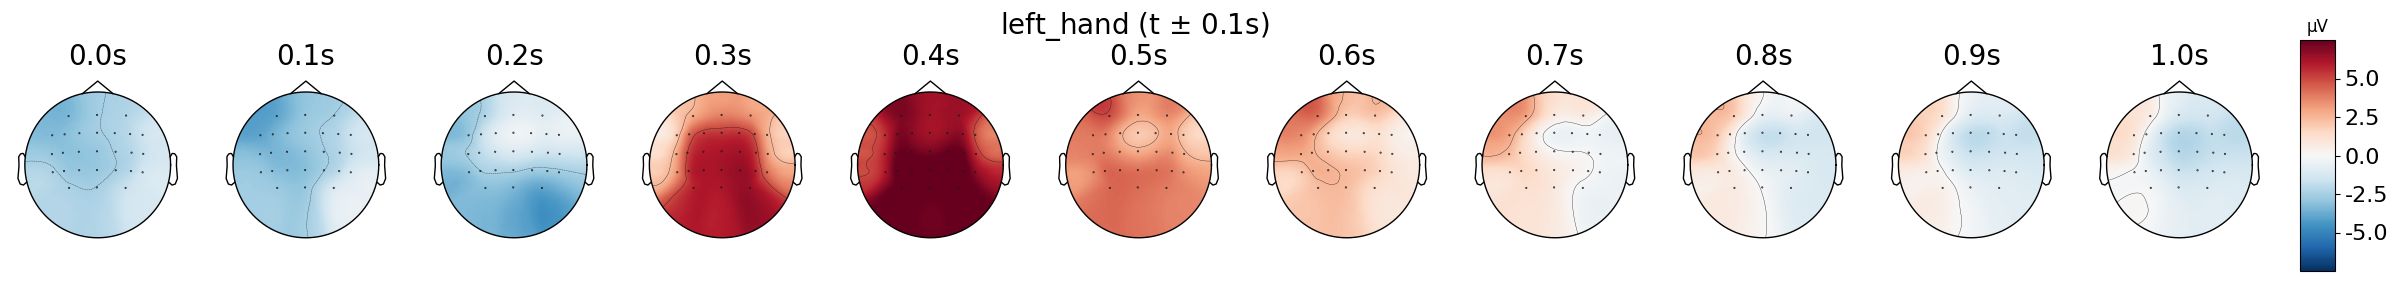

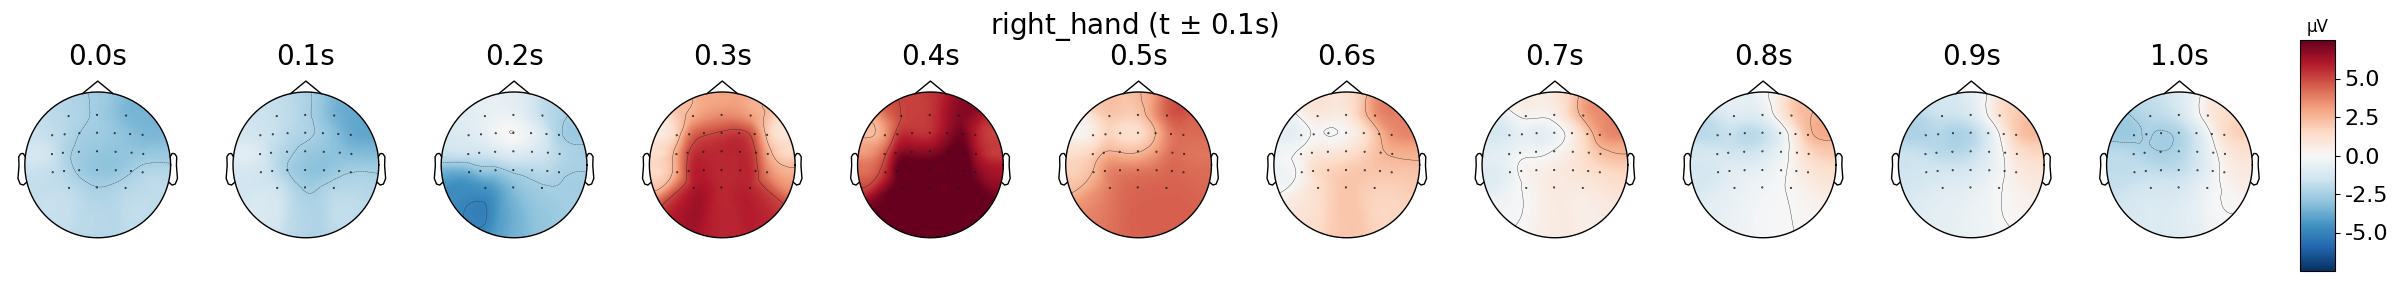

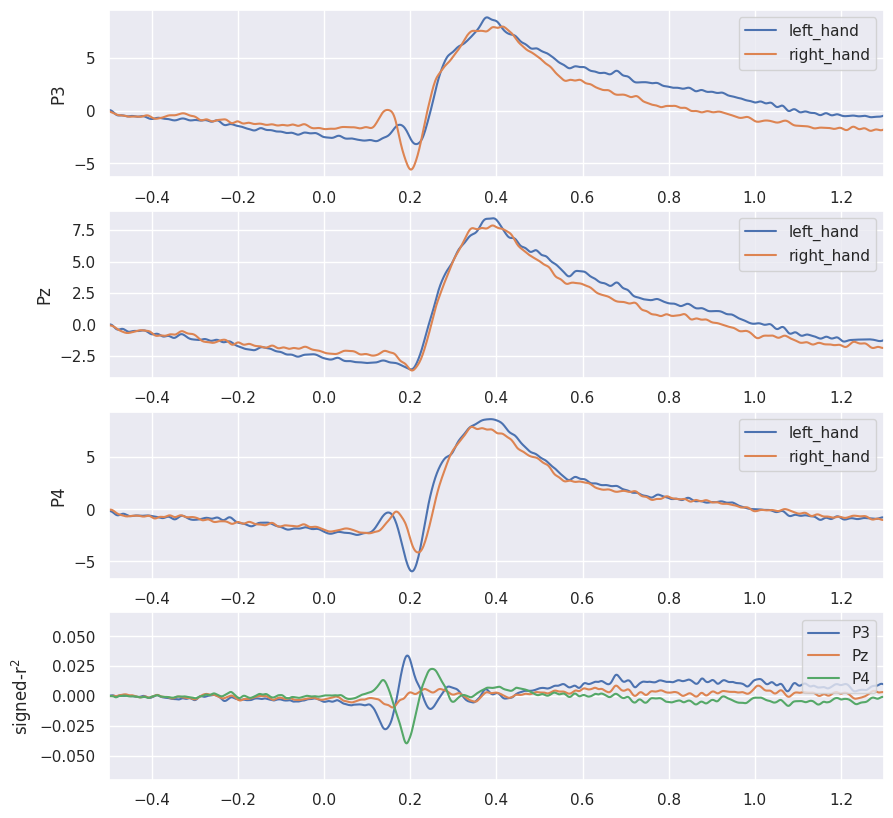

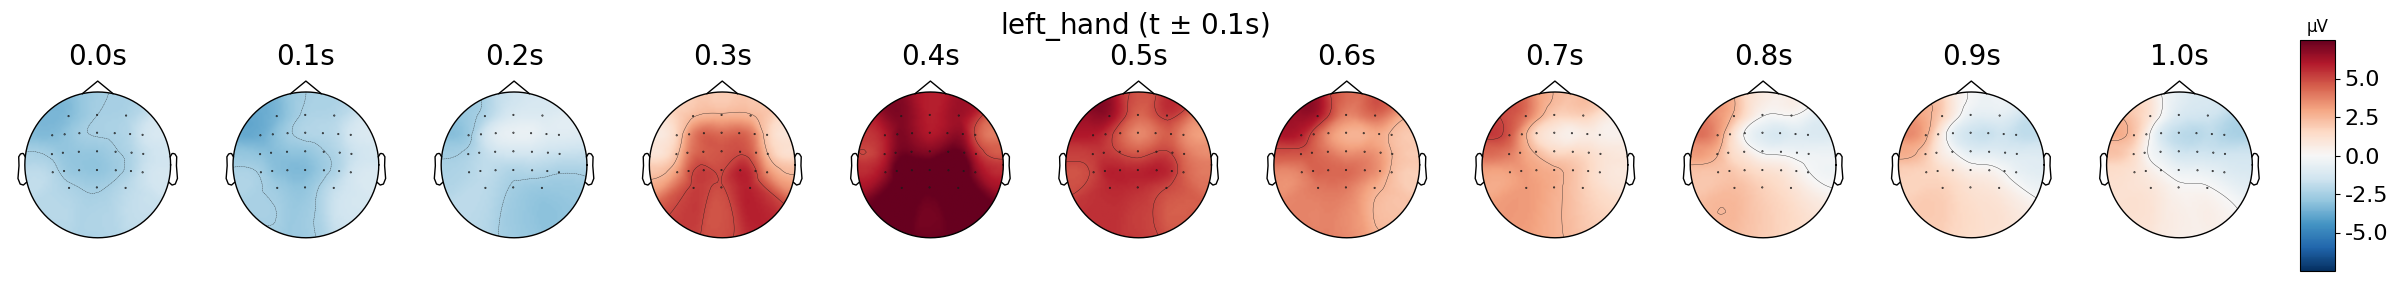

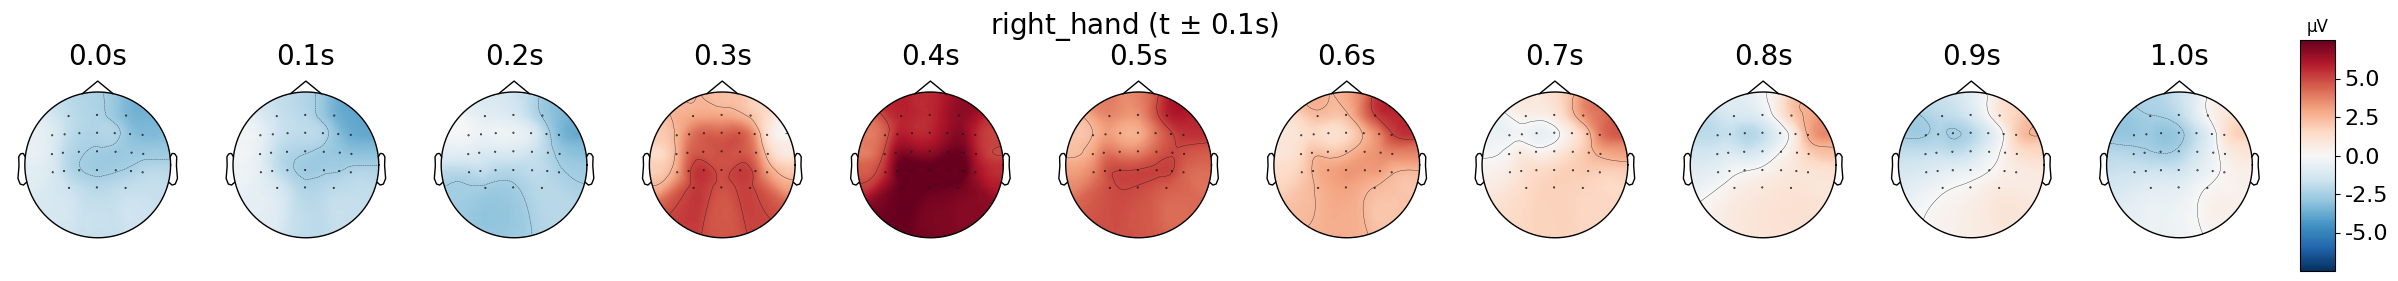

In [6]:
def plot_erp(subjects, fname_erp, fname_left_topo, fname_right_topo, vlim_topo, vlim_r2):
    left_hand_evoked, right_hand_evoked = load_evoked(dataset_name, subjects=subjects)

    left_hand_evoked.crop(tmin=-0.5, tmax=1.3)
    right_hand_evoked.crop(tmin=-0.5, tmax=1.3)

    signed_r2 = load_signed_r2(dataset_name, subjects=subjects)
    signed_r2.crop(tmin=-0.5, tmax=1.3)

    sns.set()
    fig, ax = plt.subplots(4, 1, figsize=(10, 10))

    ax[0].set_ylabel("P3")
    sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="P3", units="uV").squeeze(), ax=ax[0],
                 label="left_hand")
    sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="P3", units="uV").squeeze(), ax=ax[0],
                 label="right_hand")

    ax[1].set_ylabel("Pz")
    sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="Pz", units="uV").squeeze(), ax=ax[1],
                 label="left_hand")
    sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="Pz", units="uV").squeeze(), ax=ax[1],
                 label="right_hand")

    ax[2].set_ylabel("P4")
    sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="P4", units="uV").squeeze(), ax=ax[2],
                 label="left_hand")
    sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="P4", units="uV").squeeze(), ax=ax[2],
                 label="right_hand")

    ax[3].set_ylabel("signed-r$^2$")
    sns.lineplot(x=signed_r2.times, y=signed_r2.get_data(picks="P3").squeeze(), ax=ax[3], label="P3")
    sns.lineplot(x=signed_r2.times, y=signed_r2.get_data(picks="Pz").squeeze(), ax=ax[3], label="Pz")
    sns.lineplot(x=signed_r2.times, y=signed_r2.get_data(picks="P4").squeeze(), ax=ax[3], label="P4")
    ax[3].set_ylim(vlim_r2)

    for a in ax:
        a.set_xlim([-0.5, 1.3])
        a.legend(loc="upper right")

    fig.savefig(fname_erp, dpi=600)

    times = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    plt.rcdefaults()
    fig, axes = plt.subplots(1, 12, figsize=(30, 3),
                             gridspec_kw={"width_ratios": [1] * 11 + [0.2]}
                             )
    left_hand_evoked.info.set_montage("standard_1005")
    im = left_hand_evoked.plot_topomap(times=times, average=0.1,
                                       show=False,
                                       vlim=vlim_topo, axes=axes, colorbar=True)
    axes[-1].tick_params(labelsize=16)
    for ax, t in zip(axes[0:11], times):
        ax.set_title(f"{t}s", fontsize=20)
    fig.suptitle(f"left_hand (t $\pm$ 0.1s)", fontsize=20)

    fig.savefig(fname_left_topo, dpi=300)

    fig, axes = plt.subplots(1, 12, figsize=(30, 3),
                             gridspec_kw={"width_ratios": [1] * 11 + [0.2]}
                             )
    right_hand_evoked.info.set_montage("standard_1005")
    im = right_hand_evoked.plot_topomap(times=times, average=0.1,
                                        show=False, vlim=vlim_topo, axes=axes)
    axes[-1].tick_params(labelsize=16)
    for ax, t in zip(axes[0:11], times):
        ax.set_title(f"{t}s", fontsize=20)
    fig.suptitle("right_hand (t $\pm$ 0.1s)", fontsize=20)

    fig.savefig(fname_right_topo, dpi=300)


if dataset_name == "Dreyer2023":
    vlim_topo = [-7.5, 7.5]
    vlim_r2 = [-0.07, 0.07]
elif dataset_name == "Lee2019_MI":
    vlim_topo = [-16, 16]
    vlim_r2 = [-0.04, 0.04]

plot_erp(subjects=big, fname_erp=save_base / f"{dataset_name}_visual_erp_big_gap.png",
         fname_left_topo=save_base / f"{dataset_name}_visual_erp_topo_left_hand_big_gap",
         fname_right_topo=save_base / f"{dataset_name}_visual_erp_topo_right_hand_big_gap", vlim_topo=vlim_topo,
         vlim_r2=vlim_r2)

plot_erp(subjects=small, fname_erp=save_base / f"{dataset_name}_visual_erp_small_gap.png",
         fname_left_topo=save_base / f"{dataset_name}_visual_erp_topo_left_hand_small_gap",
         fname_right_topo=save_base / f"{dataset_name}_visual_erp_topo_right_hand_small_gap", vlim_topo=vlim_topo,
         vlim_r2=vlim_r2)
